<a href="https://colab.research.google.com/github/ignaciomdlp/Tarea-2---Optimizaci-n/blob/main/Tarea2_Optimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import math
import time

def generar_solucion_inicial(num_trabajos, num_maquinas):
    solucion = []
    for i in range(num_trabajos):
        solucion.extend([i] * num_maquinas)
    random.shuffle(solucion)
    return solucion

def generar_vecino(solucion):
    vecino = solucion.copy()
    idx1, idx2 = random.sample(range(len(vecino)), 2)
    vecino[idx1], vecino[idx2] = vecino[idx2], vecino[idx1]
    return vecino

def calcular_makespan(solucion, matriz_tiempos, matriz_maquinas):
    num_trabajos = len(matriz_tiempos)
    num_maquinas = len(matriz_tiempos[0])

    tiempo_fin_maquina = [0] * num_maquinas
    tiempo_fin_trabajo = [0] * num_trabajos

    operacion_actual = [0] * num_trabajos

    for trabajo in solucion:
        op = operacion_actual[trabajo]
        maquina_requerida = matriz_maquinas[trabajo][op]
        tiempo_requerido = matriz_tiempos[trabajo][op]

        inicio = max(tiempo_fin_trabajo[trabajo], tiempo_fin_maquina[maquina_requerida])
        fin = inicio + tiempo_requerido

        tiempo_fin_trabajo[trabajo] = fin
        tiempo_fin_maquina[maquina_requerida] = fin
        operacion_actual[trabajo] += 1

    return max(tiempo_fin_maquina)

def simulated_annealing(matriz_tiempos, matriz_maquinas, T_inicial, alpha, iteraciones_nivel, T_min, tiempo_maximo):
    num_trabajos = len(matriz_tiempos)
    num_maquinas = len(matriz_tiempos[0])

    solucion_actual = generar_solucion_inicial(num_trabajos, num_maquinas)
    makespan_actual = calcular_makespan(solucion_actual, matriz_tiempos, matriz_maquinas)

    mejor_solucion = solucion_actual.copy()
    mejor_makespan = makespan_actual

    T = T_inicial
    tiempo_inicio = time.time()

    while T > T_min and (time.time() - tiempo_inicio) < tiempo_maximo:
        for _ in range(iteraciones_nivel):
            vecino = generar_vecino(solucion_actual)
            makespan_vecino = calcular_makespan(vecino, matriz_tiempos, matriz_maquinas)

            delta_E = makespan_vecino - makespan_actual

            if delta_E < 0 or random.random() < math.exp(-delta_E / T):
                solucion_actual = vecino
                makespan_actual = makespan_vecino

                if makespan_actual < mejor_makespan:
                    mejor_solucion = solucion_actual.copy()
                    mejor_makespan = makespan_actual

        T *= alpha

    return mejor_solucion, mejor_makespan

INICIANDO 10 Ejecuciones por Instancia

Procesando: instancia01_facil.txt...
  Corrida 1/10 -> Makespan: 55
  Corrida 2/10 -> Makespan: 55
  Corrida 3/10 -> Makespan: 55
  Corrida 4/10 -> Makespan: 55
  Corrida 5/10 -> Makespan: 55
  Corrida 6/10 -> Makespan: 55
  Corrida 7/10 -> Makespan: 55
  Corrida 8/10 -> Makespan: 55
  Corrida 9/10 -> Makespan: 55
  Corrida 10/10 -> Makespan: 55

--- RESUMEN PARA EL INFORME: instancia01_facil.txt ---
-> SECCIÓN 3 (Mejores Soluciones):
   Mejor Función Objetivo (Makespan): 55
   Valores de las variables (Secuencia):
   [2, 1, 5, 0, 1, 0, 4, 3, 4, 0, 3, 2, 3, 2, 1, 2, 5, 5, 1, 3, 4, 5, 1, 2, 0, 3, 4, 2, 5, 0, 1, 0, 5, 4, 3, 4]
-> SECCIÓN 4 (Resultados):
   Media: 55.00
   Desviación Estándar: 0.00
-----------------------------------------------------------------

Procesando: instancia02_media.txt...
  Corrida 1/10 -> Makespan: 1060
  Corrida 2/10 -> Makespan: 1059
  Corrida 3/10 -> Makespan: 1042
  Corrida 4/10 -> Makespan: 1078
  Corrida 5/10 -> M

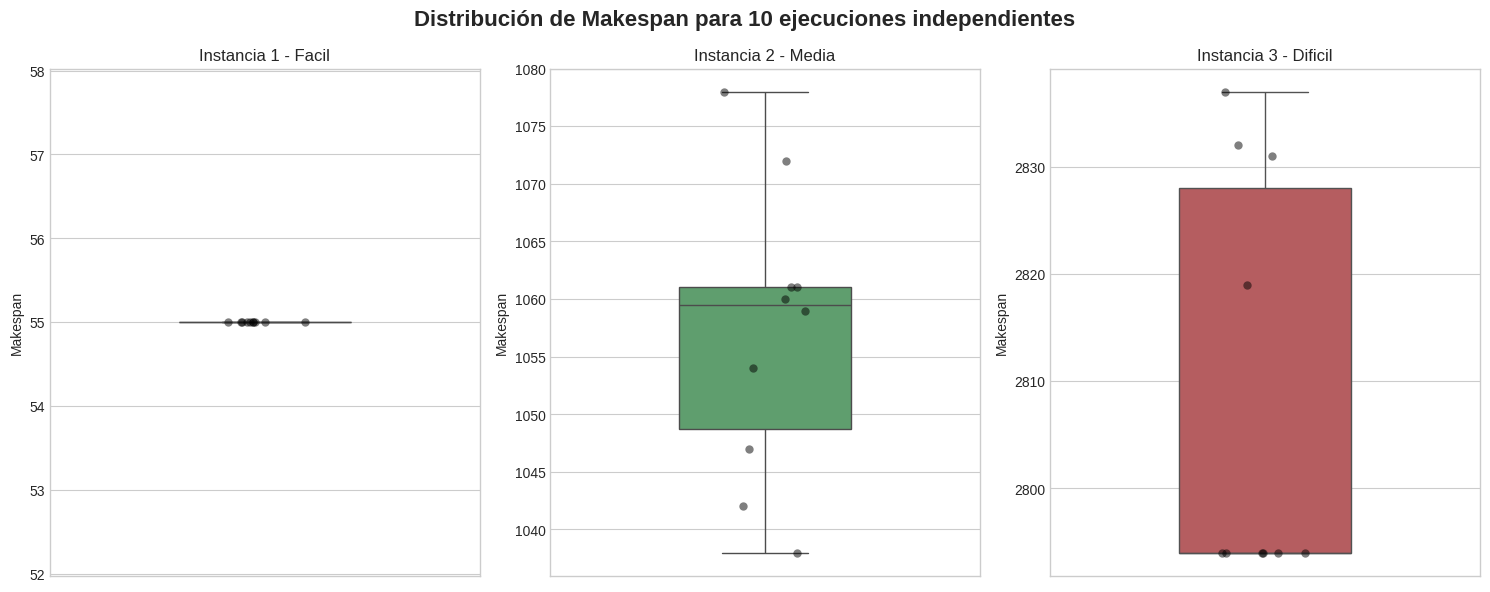

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

archivos_instancias = [
    'instancia01_facil.txt',
    'instancia02_media.txt',
    'instancia03_dificil.txt'
]

# Parámetros
T_inicial = 100
factor_enfriamiento = 0.9
iteraciones_nivel = 100
T_minima = 0.01
tiempo_limite = 60

num_ejecuciones = 10
resultados_makespan = {}

print("INICIANDO 10 Ejecuciones por Instancia\n" + "="*65)

for archivo in archivos_instancias:
    if not os.path.exists(archivo):
        print(f"[ERROR] Archivo {archivo} no encontrado.")
        continue

    print(f"\nProcesando: {archivo}...")
    matriz_tiempos, matriz_maquinas = leer_instancia(archivo)

    lista_makespans = []

    mejor_makespan_absoluto = float('inf')
    mejor_secuencia_absoluta = []

    for i in range(num_ejecuciones):
        secuencia, makespan = simulated_annealing(
            matriz_tiempos, matriz_maquinas,
            T_inicial, factor_enfriamiento, iteraciones_nivel, T_minima, tiempo_limite
        )

        lista_makespans.append(makespan)

        if makespan < mejor_makespan_absoluto:
            mejor_makespan_absoluto = makespan
            mejor_secuencia_absoluta = secuencia

        print(f"  Corrida {i+1}/10 -> Makespan: {makespan}")

    resultados_makespan[archivo] = lista_makespans

    media = np.mean(lista_makespans)
    desviacion = np.std(lista_makespans, ddof=1)

    print(f"\n--- RESUMEN PARA EL INFORME: {archivo} ---")
    print(f"-> SECCIÓN 3 (Mejores Soluciones):")
    print(f"   Mejor Función Objetivo (Makespan): {mejor_makespan_absoluto}")
    print(f"   Valores de las variables (Secuencia):\n   {mejor_secuencia_absoluta}")
    print(f"-> SECCIÓN 4 (Resultados):")
    print(f"   Media: {media:.2f}")
    print(f"   Desviación Estándar: {desviacion:.2f}")
    print("-" * 65)

# ============================================
# GENERACIÓN DE GRÁFICOS DE CAJAS (BOXPLOTS)
# ============================================

df_resultados = pd.DataFrame(resultados_makespan)

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Distribución de Makespan para 10 ejecuciones independientes', fontsize=16, fontweight='bold')

colores = ['#4C72B0', '#55A868', '#C44E52'] # Azul, Verde, Rojo

for idx, col in enumerate(df_resultados.columns):
    sns.boxplot(y=df_resultados[col], ax=axes[idx], color=colores[idx], width=0.4)
    sns.stripplot(y=df_resultados[col], ax=axes[idx], color='black', alpha=0.5, size=6, jitter=True)

    titulo = col.replace('.txt', '').replace('0', ' ').replace('_', ' - ').title()
    axes[idx].set_title(titulo, fontsize=12)
    axes[idx].set_ylabel('Makespan')

plt.tight_layout()
plt.show()